# Action Recognition for Real-Time Safety Monitoring

This notebook builds a system that watches short video clips and classifies the activity into one of **5 categories**:
- `0` → normal_activity
- `1` → fight
- `2` → fall
- `3` → crowd_anomaly *(no videos for this class in the dataset — that is expected)*
- `4` → running_panic

**Architecture:** A Two-Stream CNN-LSTM model.
- Each frame is passed through a ResNet18 to extract spatial features.
- A 4th channel (frame difference = motion) is stacked on the RGB frame.
- An LSTM then reads the sequence of per-frame features to understand temporal patterns.

---
### Setup Requirements
Install the following before running (run once in terminal):
```
pip install torch torchvision opencv-python scikit-learn pandas matplotlib seaborn tqdm
```

### Expected folder structure
```
action_recognition_project/
├── Videos.zip          ← already downloaded
└── data/               ← will be created automatically
    └── Videos/
        ├── Sit/
        ├── Stand/
        ├── Hit/
        └── ...         ← one folder per action category
```

In [104]:
import os
import zipfile
import shutil

# ---- Project Path ----
PROJECT_DIR = os.getcwd()

# ---- Paths ----
DATA_DIR = os.path.join(PROJECT_DIR, "data")
VIDEOS_ZIP = os.path.join(PROJECT_DIR, "Videos.zip")
EXTRACTED_VIDEOS_DIR = os.path.join(DATA_DIR, "Videos")

# ---- Create data folder ----
os.makedirs(DATA_DIR, exist_ok=True)

# ---- Check zip file ----
if not os.path.exists(VIDEOS_ZIP):
    raise FileNotFoundError(f"Videos.zip not found at: {VIDEOS_ZIP}")

# ---- Extract dataset ----
if not os.path.exists(EXTRACTED_VIDEOS_DIR):
    print("Extracting dataset...")

    with zipfile.ZipFile(VIDEOS_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    # Handle possible nested extraction like data/data/Videos/Videos
    nested_paths = [
        os.path.join(DATA_DIR, "data", "Videos", "Videos"),
        os.path.join(DATA_DIR, "Videos", "Videos"),
    ]

    for nested_path in nested_paths:
        if os.path.exists(nested_path) and not os.path.exists(EXTRACTED_VIDEOS_DIR):
            shutil.move(nested_path, EXTRACTED_VIDEOS_DIR)

    print("Extraction complete!")
else:
    print("Dataset already extracted.")

print("Videos directory:", EXTRACTED_VIDEOS_DIR)
print("Folders found:", os.listdir(EXTRACTED_VIDEOS_DIR)[:10])


Dataset already extracted.
Videos directory: c:\Users\arj20\action_recognition_project\data\Videos
Folders found: ['fall', 'grab', 'gun', 'hit', 'kick', 'lying_down', 'run', 'sit', 'sneak', 'stand']


In [105]:
print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Current directory: c:\Users\arj20\action_recognition_project
Files: ['.venv', 'action_project.ipynb', 'action_project_clean_final.ipynb', 'action_recognition_local.ipynb', 'action_recognition_project', 'data', 'dataset.py', 'extract_frames.py', 'model.py', 'predict.py', 'quick_test.py', 'train.py', 'Videos.zip']


In [106]:
print("DATA_DIR:", DATA_DIR)
print("Inside DATA_DIR:", os.listdir(DATA_DIR))
print("Inside data/data:", os.listdir(os.path.join(DATA_DIR, "data")))

DATA_DIR: c:\Users\arj20\action_recognition_project\data
Inside DATA_DIR: ['best_model.pth', 'data', 'frames', 'submission.csv', 'test', 'test.csv', 'train', 'train.csv', 'unified_dataset.csv', 'val.csv', 'Videos']
Inside data/data: ['test.csv', 'train.csv', 'unified_dataset.csv', 'val.csv', 'Videos']


## Step 0 — Setup: Unzip Videos & Build the Dataset CSV

In [107]:
import os
import zipfile
import glob
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2

# ---- Project paths ----
PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
ZIP_PATH = os.path.join(PROJECT_ROOT, "Videos.zip")

# Final expected video folder:
# action_recognition_project/data/Videos/<action folders>
VIDEO_ROOT = os.path.join(DATA_ROOT, "Videos")

os.makedirs(DATA_ROOT, exist_ok=True)

# ---- Extract dataset if needed ----
if not os.path.exists(VIDEO_ROOT):
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(f"Videos.zip not found at: {ZIP_PATH}")

    print("Extracting Videos.zip ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)

    # Fix common nested zip structures if they appear
    possible_nested_roots = [
        os.path.join(DATA_ROOT, "data", "Videos", "Videos"),
        os.path.join(DATA_ROOT, "Videos", "Videos"),
    ]

    for nested_root in possible_nested_roots:
        if os.path.exists(nested_root) and not os.path.exists(VIDEO_ROOT):
            shutil.move(nested_root, VIDEO_ROOT)

    print("Done extracting.")
else:
    print("Videos folder already exists, skipping extraction.")

# ---- Validate path ----
if not os.path.exists(VIDEO_ROOT):
    raise FileNotFoundError(
        "Could not find extracted videos folder. "
        f"Expected it at: {VIDEO_ROOT}"
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Videos root  : {VIDEO_ROOT}")
print("Sample folders:", os.listdir(VIDEO_ROOT)[:10])


Videos folder already exists, skipping extraction.
Project root : c:\Users\arj20\action_recognition_project
Videos root  : c:\Users\arj20\action_recognition_project\data\Videos
Sample folders: ['fall', 'grab', 'gun', 'hit', 'kick', 'lying_down', 'run', 'sit', 'sneak', 'stand']


In [108]:
from pathlib import Path
import re

# Map dataset folders to the 5 target classes
FOLDER_TO_CLASS = {
    "sit":         {"label": 0, "class_name": "normal_activity"},
    "stand":       {"label": 0, "class_name": "normal_activity"},
    "walk":        {"label": 0, "class_name": "normal_activity"},

    "hit":         {"label": 1, "class_name": "fight"},
    "kick":        {"label": 1, "class_name": "fight"},
    "struggle":    {"label": 1, "class_name": "fight"},
    "grab":        {"label": 1, "class_name": "fight"},
    "throw":       {"label": 1, "class_name": "fight"},
    "gun":         {"label": 1, "class_name": "fight"},

    "fall":        {"label": 2, "class_name": "fall"},
    "lying_down":  {"label": 2, "class_name": "fall"},
    "lyingdown":   {"label": 2, "class_name": "fall"},

    "run":         {"label": 4, "class_name": "running_panic"},
}


CLASS_NAMES = {
    0: "normal_activity",
    1: "fight",
    2: "fall",
    3: "crowd_anomaly",
    4: "running_panic",
}

def normalize_name(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def build_dataset_csv(video_root, output_csv_path):
    video_root = Path(video_root)
    output_csv_path = Path(output_csv_path)

    print(f"Scanning for videos inside: {video_root} ...")

    video_extensions = {".mp4", ".avi", ".mov", ".mkv"}
    all_videos = sorted(
        path for path in video_root.rglob("*")
        if path.is_file() and path.suffix.lower() in video_extensions
    )

    if not all_videos:
        raise FileNotFoundError(f"No videos found. Check VIDEO_ROOT: {video_root}")

    data = []
    unmapped = []

    for video_path in all_videos:
        assigned_info = None
        assigned_category = None

        # Match using folder names first
        folder_names = [normalize_name(part) for part in video_path.parts]

        for folder_name in reversed(folder_names):
            if folder_name in FOLDER_TO_CLASS:
                assigned_info = FOLDER_TO_CLASS[folder_name]
                assigned_category = folder_name
                break

        # Fallback: match using filename
        if assigned_info is None:
            filename = normalize_name(video_path.stem)

            for category, info in FOLDER_TO_CLASS.items():
                if category in filename:
                    assigned_info = info
                    assigned_category = category
                    break

        if assigned_info is None:
            unmapped.append(str(video_path))
            continue

        data.append({
            "video_path": str(video_path),
            "label": assigned_info["label"],
            "class_name": assigned_info["class_name"],
            "original_category": assigned_category,
        })

    df = pd.DataFrame(data)

    if df.empty:
        raise ValueError("Videos were found, but none matched FOLDER_TO_CLASS.")

    print("\n--- Class Distribution ---")
    print(df["class_name"].value_counts())

    print("\n--- Original Category Distribution ---")
    print(df["original_category"].value_counts().sort_index())

    print("\n--- Label Distribution ---")
    print(df["label"].value_counts().sort_index())

    print("\nNote: crowd_anomaly (class 3) has 0 videos. That is expected for this dataset.")

    if unmapped:
        print(f"\nWarning: {len(unmapped)} videos were not mapped.")
        print("First few unmapped videos:")
        for path in unmapped[:10]:
            print(path)
    else:
        print("\nAll videos mapped successfully.")

    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv_path, index=False)

    print(f"\nSaved dataset CSV to: {output_csv_path}")
    return df

csv_path = os.path.join(DATA_ROOT, "unified_dataset.csv")
df = build_dataset_csv(VIDEO_ROOT, csv_path)
df.head()


Scanning for videos inside: c:\Users\arj20\action_recognition_project\data\Videos ...

--- Class Distribution ---
class_name
fight              979
normal_activity    599
fall               396
running_panic      200
Name: count, dtype: int64

--- Original Category Distribution ---
original_category
fall          200
grab          200
gun           195
hit           188
kick           98
lying_down    196
run           200
sit           199
stand         200
struggle      198
throw         100
walk          200
Name: count, dtype: int64

--- Label Distribution ---
label
0    599
1    979
2    396
4    200
Name: count, dtype: int64

Note: crowd_anomaly (class 3) has 0 videos. That is expected for this dataset.

First few unmapped videos:
c:\Users\arj20\action_recognition_project\data\Videos\sneak\UCFCRIME_Burglary035_sneak_1.mp4
c:\Users\arj20\action_recognition_project\data\Videos\sneak\UCFCRIME_Burglary042_sneak_1.mp4
c:\Users\arj20\action_recognition_project\data\Videos\sneak\UCFCRIM

,video_path,label,class_name,original_category
0,c:\Users\arj20\action_recognition_project\data...,2,fall,fall
1,c:\Users\arj20\action_recognition_project\data...,2,fall,fall
2,c:\Users\arj20\action_recognition_project\data...,2,fall,fall
3,c:\Users\arj20\action_recognition_project\data...,2,fall,fall
4,c:\Users\arj20\action_recognition_project\data...,2,fall,fall


In [109]:
# Split into Train / Validation / Test  (68% / 12% / 20%)
if df.empty:
    raise ValueError("Dataset dataframe is empty. Run the dataset CSV cell first.")

train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42,
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    stratify=train_val_df["label"],
    random_state=42,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(os.path.join(DATA_ROOT, "train.csv"), index=False)
val_df.to_csv(os.path.join(DATA_ROOT, "val.csv"), index=False)
test_df.to_csv(os.path.join(DATA_ROOT, "test.csv"), index=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print("\n--- Train Label Distribution ---")
print(train_df["label"].value_counts().sort_index())

print("\n--- Val Label Distribution ---")
print(val_df["label"].value_counts().sort_index())

print("\n--- Test Label Distribution ---")
print(test_df["label"].value_counts().sort_index())

# Quick sanity-check: try opening 3 random videos from each split
def sanity_check(splits_dict, samples_per_split=3):
    corrupt = []

    for split_name, dataframe in splits_dict.items():
        print(f"\nChecking {samples_per_split} random videos from {split_name}...")

        sample = dataframe.sample(
            min(samples_per_split, len(dataframe)),
            random_state=42,
        )

        for _, row in sample.iterrows():
            video_path = row["video_path"]

            cap = cv2.VideoCapture(video_path)
            opened = cap.isOpened()

            if not opened:
                print(f"  FAILED: {video_path}")
                corrupt.append(video_path)
            else:
                frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                fps = cap.get(cv2.CAP_PROP_FPS)
                print(f"  OK [{row['class_name']}] - {frames} frames, {fps:.2f} fps")

            cap.release()

    return corrupt

bad = sanity_check({
    "Train": train_df,
    "Val": val_df,
    "Test": test_df,
})

if bad:
    print(f"\nFound {len(bad)} corrupt file(s). They will be skipped during training.")
else:
    print("\nAll sampled files look healthy!")


Train: 1478 | Val: 261 | Test: 435

--- Train Label Distribution ---
label
0    407
1    666
2    269
4    136
Name: count, dtype: int64

--- Val Label Distribution ---
label
0     72
1    117
2     48
4     24
Name: count, dtype: int64

--- Test Label Distribution ---
label
0    120
1    196
2     79
4     40
Name: count, dtype: int64

Checking 3 random videos from Train...
  OK [normal_activity] - 90 frames, 30.00 fps
  OK [fight] - 150 frames, 30.00 fps
  OK [normal_activity] - 30 frames, 30.00 fps

Checking 3 random videos from Val...
  OK [fall] - 90 frames, 30.00 fps
  OK [normal_activity] - 120 frames, 30.00 fps
  OK [fight] - 60 frames, 30.00 fps

Checking 3 random videos from Test...
  OK [normal_activity] - 120 frames, 30.00 fps
  OK [fight] - 270 frames, 30.00 fps
  OK [fight] - 120 frames, 30.00 fps

All sampled files look healthy!


## Step 1 — Imports and Global Configuration

In [110]:
import os
import random
import time
import copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim.lr_scheduler import StepLR
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---- CONFIG ----
CONFIG = {
    "num_frames": 8,
    "image_size": 112,
    "batch_size": 8,
    "num_epochs": 10,
    "learning_rate": 1e-5,
    "num_classes": 5,
    "seed": 42,
    "force_retrain": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

# In Windows notebooks, num_workers=0 is safest.
# If training is stable but slow, you can try 2 later.
NUM_WORKERS = 0 if os.name == "nt" else 2

CLASS_NAMES = {
    0: "normal_activity",
    1: "fight",
    2: "fall",
    3: "crowd_anomaly",
    4: "running_panic",
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        # Deterministic mode is more reproducible but can be slower.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

print(f"Using device: {CONFIG['device']}")
print(f"num_workers : {NUM_WORKERS}")


Using device: cuda
num_workers : 0


## Step 2 — Frame Extraction + Motion Channel

In [111]:
def extract_frames(video_path, num_frames=8, target_size=(112, 112)):
    """
    Extract evenly spaced RGB frames from a video.

    Returns:
        frames: np.ndarray of shape (num_frames, H, W, 3), dtype uint8
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return np.zeros((num_frames, target_size[1], target_size[0], 3), dtype=np.uint8)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((num_frames, target_size[1], target_size[0], 3), dtype=np.uint8)

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ret, frame = cap.read()

        if not ret or frame is None:
            continue

        frame = cv2.resize(frame, target_size)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return np.zeros((num_frames, target_size[1], target_size[0], 3), dtype=np.uint8)

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    return np.array(frames, dtype=np.uint8)


## Step 3 — Visualise Frames + Motion Channel (Sanity Check)

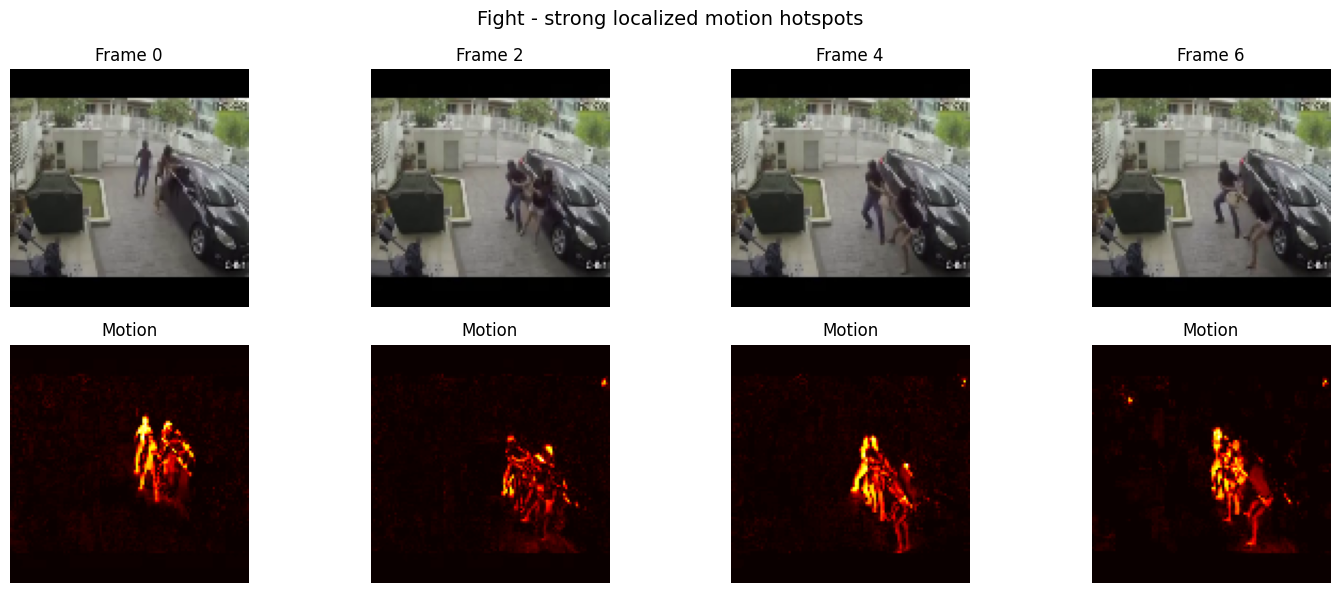

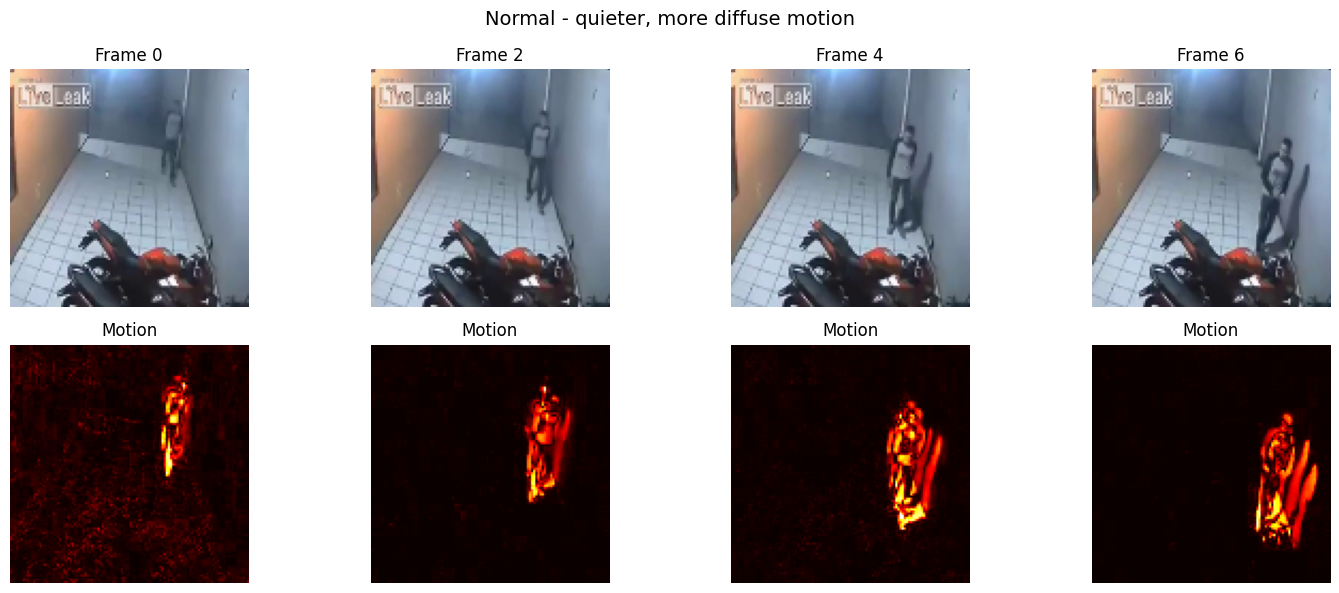

In [112]:
train_df = pd.read_csv(os.path.join(DATA_ROOT, "train.csv"))

def get_example_video(dataframe, class_name):
    matches = dataframe[dataframe["class_name"] == class_name]

    if matches.empty:
        raise ValueError(f"No videos found for class: {class_name}")

    return matches.iloc[0]["video_path"]

fight_path = get_example_video(train_df, "fight")
normal_path = get_example_video(train_df, "normal_activity")


def extract_motion_frames(frames):
    """
    Stack RGB frames with a 4th motion channel.

    Input:
        frames: uint8 array, shape (T, H, W, 3)

    Output:
        four_channel_frames: float32 array, shape (T, H, W, 4)
    """
    frames = frames.astype(np.float32)

    motion = np.abs(frames[1:] - frames[:-1])

    if len(motion) == 0:
        motion = np.zeros_like(frames[:, :, :, :1])
    else:
        motion = np.concatenate([motion, motion[-1:]], axis=0)
        motion = motion.mean(axis=-1, keepdims=True)

    four_channel_frames = np.concatenate([frames, motion], axis=-1)
    return four_channel_frames.astype(np.float32)


def plot_motion_comparison(video_path, title):
    size = CONFIG["image_size"]

    frames = extract_frames(
        video_path,
        num_frames=CONFIG["num_frames"],
        target_size=(size, size),
    )

    four_c = extract_motion_frames(frames)

    show_at = [0, 2, 4, 6]

    fig, axes = plt.subplots(2, 4, figsize=(15, 6))
    fig.suptitle(title, fontsize=14)

    for col, idx in enumerate(show_at):
        axes[0, col].imshow(four_c[idx, :, :, :3].astype(np.uint8))
        axes[0, col].axis("off")
        axes[0, col].set_title(f"Frame {idx}")

        axes[1, col].imshow(four_c[idx, :, :, 3], cmap="hot")
        axes[1, col].axis("off")
        axes[1, col].set_title("Motion")

    plt.tight_layout()
    plt.show()


plot_motion_comparison(fight_path, "Fight - strong localized motion hotspots")
plot_motion_comparison(normal_path, "Normal - quieter, more diffuse motion")


## Step 4 — Data Augmentation Transforms

In [113]:
def apply_transforms(frames_4c, is_train):
    """
    Input : numpy array (num_frames, H, W, 4), values in 0-255
    Output: PyTorch tensor (num_frames, 4, H, W), normalized
    """
    image_size = CONFIG["image_size"]

    # Rearrange from (T, H, W, C) to (T, C, H, W), then scale to 0-1
    tensor = torch.from_numpy(frames_4c).permute(0, 3, 1, 2).float() / 255.0

    if is_train:
        # Flip all 4 channels together so the motion channel stays aligned
        if random.random() > 0.5:
            tensor = TF.hflip(tensor)

        # Small random rotation applied to all channels together
        angle = random.uniform(-10, 10)
        tensor = TF.rotate(tensor, angle)

        # Color jitter only on RGB channels, not the motion channel
        jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1)

        rgb = tensor[:, :3, :, :]
        motion = tensor[:, 3:, :, :]

        rgb = torch.stack([jitter(frame) for frame in rgb], dim=0)

        tensor = torch.cat([rgb, motion], dim=1)
    else:
        tensor = TF.center_crop(tensor, output_size=(image_size, image_size))

    # ImageNet stats for RGB, simple 0.5/0.5 scaling for motion
    mean = torch.tensor([0.485, 0.456, 0.406, 0.5], dtype=tensor.dtype).view(1, 4, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225, 0.5], dtype=tensor.dtype).view(1, 4, 1, 1)

    tensor = (tensor - mean) / std

    return tensor


## Step 5 — Dataset Class and DataLoaders

In [114]:
import os
import re
from pathlib import Path

# Keep class names consistent with CSV labels.
# Do not remap running_panic to crowd_anomaly unless your frame folders are actually named that way.
FRAME_CLASS_MAP = {}

class VideoDataset(Dataset):
    def __init__(self, df, is_train=True, split_name="train"):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.split_name = split_name

        self.num_frames = CONFIG["num_frames"]
        self.target_size = (CONFIG["image_size"], CONFIG["image_size"])

        self.frame_root = os.path.join(DATA_ROOT, "frames", split_name)

        self._frame_cache = {}
        self.cache_limit = 200

    def __len__(self):
        return len(self.df)

    def _natural_key(self, path):
        stem = Path(path).stem
        match = re.search(r"(\d+)$", stem)
        if match:
            return (0, int(match.group(1)))
        return (1, stem)

    def _frame_class_name(self, class_name):
        return FRAME_CLASS_MAP.get(class_name, class_name)

    def _load_frame_folder(self, frame_dir):
        frame_paths = sorted(Path(frame_dir).glob("*.jpg"), key=self._natural_key)

        if not frame_paths:
            return None

        indices = np.linspace(0, len(frame_paths) - 1, self.num_frames, dtype=int)
        frame_paths = [frame_paths[i] for i in indices]

        frames = []

        for frame_path in frame_paths:
            frame = cv2.imread(str(frame_path))

            if frame is None:
                return None

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if frame.shape[:2] != self.target_size[::-1]:
                frame = cv2.resize(frame, self.target_size)

            frames.append(frame)

        return np.array(frames, dtype=np.uint8)

    def _load_cached_frames(self, row):
        video_id = Path(row["video_path"]).stem
        class_name = self._frame_class_name(row["class_name"])
        frame_dir = os.path.join(self.frame_root, class_name, video_id)

        if frame_dir in self._frame_cache:
            return self._frame_cache[frame_dir]

        if os.path.isdir(frame_dir):
            frames = self._load_frame_folder(frame_dir)

            if frames is not None:
                if len(self._frame_cache) < self.cache_limit:
                    self._frame_cache[frame_dir] = frames
                return frames

        return None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            frames = self._load_cached_frames(row)

            if frames is None:
                frames = extract_frames(
                    row["video_path"],
                    num_frames=self.num_frames,
                    target_size=self.target_size,
                )

            four_c = extract_motion_frames(frames)
            tensor = apply_transforms(four_c, self.is_train)
            label = torch.tensor(int(row["label"]), dtype=torch.long)

            return tensor, label

        except Exception as e:
            print(f"Warning: failed sample {idx}: {e}")

            zero = torch.zeros(
                self.num_frames,
                4,
                self.target_size[1],
                self.target_size[0],
                dtype=torch.float32,
            )

            return zero, torch.tensor(-1, dtype=torch.long)


def crash_proof_collate(batch):
    clean = [item for item in batch if item[1].item() != -1]

    if not clean:
        return torch.empty(0), torch.empty(0, dtype=torch.long)

    return torch.utils.data.dataloader.default_collate(clean)


# Load CSV files
train_df = pd.read_csv(os.path.join(DATA_ROOT, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_ROOT, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_ROOT, "test.csv"))

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# Class balancing
class_counts = train_df["label"].value_counts().sort_index()
class_weights = np.zeros(CONFIG["num_classes"], dtype=np.float32)

for label, count in class_counts.items():
    if count > 0:
        class_weights[int(label)] = 1.0 / count

sample_weights = torch.DoubleTensor([
    class_weights[int(label)] for label in train_df["label"].values
])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)


# Datasets
train_dataset = VideoDataset(train_df, is_train=True, split_name="train")
val_dataset = VideoDataset(val_df, is_train=False, split_name="val")
test_dataset = VideoDataset(test_df, is_train=False, split_name="test")


# DataLoaders
pin_memory = CONFIG["device"] == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    sampler=sampler,
    collate_fn=crash_proof_collate,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=crash_proof_collate,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=crash_proof_collate,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)


# Quick test
one_video, one_label = train_dataset[0]
print(f"Single sample shape: {one_video.shape}")
print(f"Single sample label: {one_label}")

sample_frames, sample_labels = next(iter(train_loader))

print(f"\nBatch tensor shape : {sample_frames.shape}")
print(
    f"Expected           : [{CONFIG['batch_size']}, {CONFIG['num_frames']}, "
    f"4, {CONFIG['image_size']}, {CONFIG['image_size']}]"
)
print(f"Batch labels       : {sample_labels}")


Single sample shape: torch.Size([8, 4, 112, 112])
Single sample label: 0

Batch tensor shape : torch.Size([8, 8, 4, 112, 112])
Expected           : [8, 8, 4, 112, 112]
Batch labels       : tensor([1, 1, 1, 0, 1, 0, 0, 2])


In [115]:
print("=" * 80)
print("DIAGNOSTIC: Frame Loading Performance Test")
print("=" * 80)

# Test path construction for first 5 samples
print("\nSample frame_dir paths (first 5 training samples):")

for i in range(min(5, len(train_df))):
    row = train_df.iloc[i]

    video_id = Path(row["video_path"]).stem
    class_name = FRAME_CLASS_MAP.get(row["class_name"], row["class_name"])

    frame_dir = os.path.join(DATA_ROOT, "frames", "train", class_name, video_id)
    exists = os.path.isdir(frame_dir)

    print(f"  [{i}] {class_name:20} | {video_id:45} | exists={exists}")

# Load batches and measure timing
print(f"\nLoading batches with batch_size={CONFIG['batch_size']}...")

import time as time_module

loader_iter = iter(train_loader)

t0 = time_module.time()
sample_batch, sample_labels = next(loader_iter)
first_load_time = time_module.time() - t0

t0 = time_module.time()
sample_batch_2, sample_labels_2 = next(loader_iter)
second_load_time = time_module.time() - t0

print(f"\nFirst batch shape : {sample_batch.shape}")
print(f"First batch labels: {sample_labels}")
print(f"First load time   : {first_load_time:.3f}s")
print(f"Per-sample time   : {first_load_time / max(len(sample_labels), 1):.4f}s")

print(f"\nSecond batch shape: {sample_batch_2.shape}")
print(f"Second load time  : {second_load_time:.3f}s")
print(f"Per-sample time   : {second_load_time / max(len(sample_labels_2), 1):.4f}s")

print("=" * 80)


DIAGNOSTIC: Frame Loading Performance Test

Sample frame_dir paths (first 5 training samples):
  [0] normal_activity      | UCFCRIME_Stealing078_walk_1                   | exists=True
  [1] fight                | UCFCRIME_Robbery102_grab_1                    | exists=True
  [2] fight                | YOUTUBE_YouTubeCCTV205_gun_1                  | exists=False
  [3] fight                | UCFCRIME_Robbery081_struggle_1                | exists=True
  [4] fall                 | YOUTUBE_YouTubeCCTV017_lying_down_2           | exists=False

Loading batches with batch_size=8...

First batch shape : torch.Size([8, 8, 4, 112, 112])
First batch labels: tensor([4, 4, 0, 2, 0, 4, 2, 0])
First load time   : 2.259s
Per-sample time   : 0.2824s

Second batch shape: torch.Size([8, 8, 4, 112, 112])
Second load time  : 2.039s
Per-sample time   : 0.2549s


## Step 6 — Two-Stage CNN-LSTM Model

In [116]:
class TwoStageActionModel(nn.Module):
    def __init__(self, num_classes=5, hidden_size=192):
        super().__init__()

        # Stage 1: Spatial feature extractor
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

        # Replace first conv layer to accept 4 channels instead of 3
        orig_conv = self.backbone.conv1

        self.backbone.conv1 = nn.Conv2d(
            in_channels=4,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        # Copy pretrained RGB weights and initialize motion channel
        with torch.no_grad():
            self.backbone.conv1.weight[:, :3, :, :] = orig_conv.weight
            self.backbone.conv1.weight[:, 3:4, :, :] = orig_conv.weight.mean(
                dim=1,
                keepdim=True,
            )

        # Output 512-d frame features
        self.backbone.fc = nn.Identity()

        # Stage 2: Temporal reasoning
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        temporal_dim = hidden_size * 2

        # Mean pooling + max pooling over time
        self.classifier = nn.Sequential(
            nn.LayerNorm(temporal_dim * 2),
            nn.Dropout(0.35),
            nn.Linear(temporal_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x: (batch, frames, channels, height, width)
        batch_size, num_frames, channels, height, width = x.shape

        x = x.reshape(batch_size * num_frames, channels, height, width)

        spatial_features = self.backbone(x)
        spatial_features = spatial_features.reshape(batch_size, num_frames, -1)

        lstm_out, _ = self.lstm(spatial_features)

        mean_pool = lstm_out.mean(dim=1)
        max_pool = lstm_out.max(dim=1).values

        temporal_features = torch.cat([mean_pool, max_pool], dim=1)

        logits = self.classifier(temporal_features)
        return logits


model = TwoStageActionModel(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])

# Quick forward-pass test
model.eval()

with torch.no_grad():
    test_input = torch.randn(
        2,
        CONFIG["num_frames"],
        4,
        CONFIG["image_size"],
        CONFIG["image_size"],
        device=CONFIG["device"],
    )

    test_output = model(test_input)

print("Model initialized successfully.")
print("Test output shape:", test_output.shape)


Model initialized successfully.
Test output shape: torch.Size([2, 5])


## Step 7 — Training Loop

In [117]:
def set_backbone_trainable(model, trainable=False):
    for param in model.backbone.parameters():
        param.requires_grad = trainable

    # Keep BatchNorm layers stable when backbone is frozen
    if not trainable:
        model.backbone.eval()


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    # If backbone is frozen, keep BatchNorm layers in eval mode
    if not any(param.requires_grad for param in model.backbone.parameters()):
        model.backbone.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    use_cuda = device == "cuda"

    progress = tqdm(loader, desc="Train", leave=False, dynamic_ncols=True)

    for inputs, labels in progress:
        if inputs.numel() == 0:
            continue

        inputs = inputs.to(device, non_blocking=use_cuda)
        labels = labels.to(device, non_blocking=use_cuda)

        if not torch.isfinite(inputs).all():
            print("Warning: skipped training batch with non-finite inputs.")
            continue

        optimizer.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = criterion(logits, labels)

        if not torch.isfinite(logits).all() or not torch.isfinite(loss):
            print("Warning: skipped training batch with NaN/Inf logits or loss.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{correct / total:.4f}",
        )

    if total == 0:
        return 0.0, 0.0

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    use_cuda = device == "cuda"

    progress = tqdm(loader, desc="Val", leave=False, dynamic_ncols=True)

    with torch.inference_mode():
        for inputs, labels in progress:
            if inputs.numel() == 0:
                continue

            inputs = inputs.to(device, non_blocking=use_cuda)
            labels = labels.to(device, non_blocking=use_cuda)

            if not torch.isfinite(inputs).all():
                print("Warning: skipped validation batch with non-finite inputs.")
                continue

            logits = model(inputs)
            loss = criterion(logits, labels)

            if not torch.isfinite(logits).all() or not torch.isfinite(loss):
                print("Warning: skipped validation batch with NaN/Inf logits or loss.")
                continue

            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress.set_postfix(
                loss=f"{running_loss / total:.4f}",
                acc=f"{correct / total:.4f}",
            )

    if total == 0:
        return 0.0, 0.0, all_preds, all_labels

    return running_loss / total, correct / total, all_preds, all_labels


Fast training mode: ResNet18 backbone is frozen.


Starting training: 10 epochs on cuda
Batch size: 8 | Train size: 1478 | Val size: 261
------------------------------------------------------------------------------------------


Epoch 01/10 (434s) train_loss=1.5017 train_acc=0.2395 val_loss=1.4345 val_acc=0.2989 BEST SAVED


Epoch 02/10 (365s) train_loss=1.4299 train_acc=0.2835 val_loss=1.3937 val_acc=0.3793 BEST SAVED


Epoch 03/10 (317s) train_loss=1.3914 train_acc=0.3085 val_loss=1.3707 val_acc=0.3831 BEST SAVED


...

Epoch 06/10 (338s) train_loss=1.3111 train_acc=0.3809 val_loss=1.3293 val_acc=0.3563


Epoch 07/10 (324s) train_loss=1.3078 train_acc=0.4073 val_loss=1.3158 val_acc=0.3755


Epoch 08/10 (333s) train_loss=1.2966 train_acc=0.4087 val_loss=1.3086 val_acc=0.3831


Epoch 09/10 (309s) train_loss=1.2994 train_acc=0.4039 val_loss=1.3074 val_acc=0.3755


Epoch 10/10 (288s) train_loss=1.2633 train_acc=0.4405 val_loss=1.2968 val_acc=0.3793
------------------------------------------------------------------------------------------
Training complete. Best validation accuracy: 0.3831


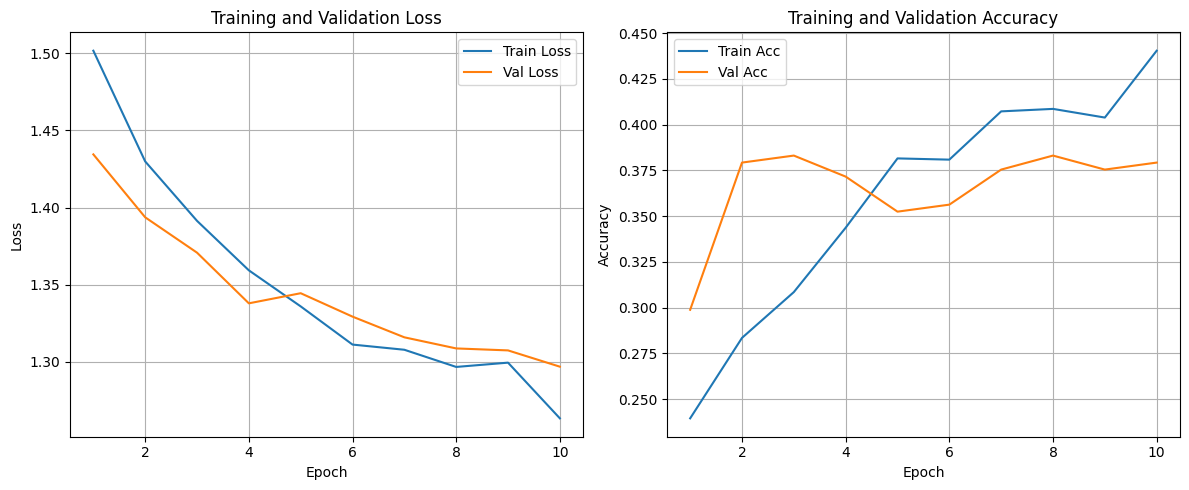

In [118]:
# Training setup
if CONFIG["device"] == "cuda":
    torch.backends.cudnn.benchmark = True

    try:
        torch.set_float32_matmul_precision("high")
    except AttributeError:
        pass

# Safer settings for the NaN issue
CONFIG["num_epochs"] = 10
CONFIG["learning_rate"] = 1e-5
CONFIG["force_retrain"] = True

BEST_MODEL_PATH = os.path.join(DATA_ROOT, "best_model.pth")

# Remove old checkpoint from earlier NaN/Inf runs
if os.path.exists(BEST_MODEL_PATH) and CONFIG.get("force_retrain", True):
    os.remove(BEST_MODEL_PATH)
    print(f"Removed old checkpoint: {BEST_MODEL_PATH}")

# Fast mode: train LSTM + classifier first, keep ResNet frozen
FAST_TRAINING = True
FREEZE_BACKBONE_EPOCHS = CONFIG["num_epochs"] if FAST_TRAINING else 3

if FAST_TRAINING:
    print("Fast training mode: ResNet18 backbone is frozen.")
    set_backbone_trainable(model, trainable=False)
else:
    print(f"Backbone frozen for first {FREEZE_BACKBONE_EPOCHS} epochs.")
    set_backbone_trainable(model, trainable=False)

criterion = nn.CrossEntropyLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=CONFIG["learning_rate"],
    weight_decay=1e-4,
)

scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# Full precision training. Do not use AMP/scaler here.
scaler = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f"Starting training: {CONFIG['num_epochs']} epochs on {CONFIG['device']}")
print(f"Batch size: {CONFIG['batch_size']} | Train size: {len(train_df)} | Val size: {len(val_df)}")
print("-" * 90)

for epoch in range(CONFIG["num_epochs"]):
    epoch_start = time.time()

    # Optional unfreeze after a few epochs if FAST_TRAINING is False
    if (not FAST_TRAINING) and epoch == FREEZE_BACKBONE_EPOCHS:
        print("Unfreezing backbone for fine-tuning.")
        set_backbone_trainable(model, trainable=True)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=CONFIG["learning_rate"] * 0.1,
            weight_decay=1e-4,
        )

        scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        CONFIG["device"],
        scaler,
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        CONFIG["device"],
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    saved = ""

    # Save only valid checkpoints
    if np.isfinite(val_loss) and np.isfinite(val_acc) and val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = " BEST SAVED"

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch + 1:02d}/{CONFIG['num_epochs']} "
        f"({epoch_time:.0f}s) "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        f"{saved}"
    )

print("-" * 90)
print(f"Training complete. Best validation accuracy: {best_val_acc:.4f}")

model.load_state_dict(best_model_wts)


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_training_history(history)


## Step 8 — Training History Plots

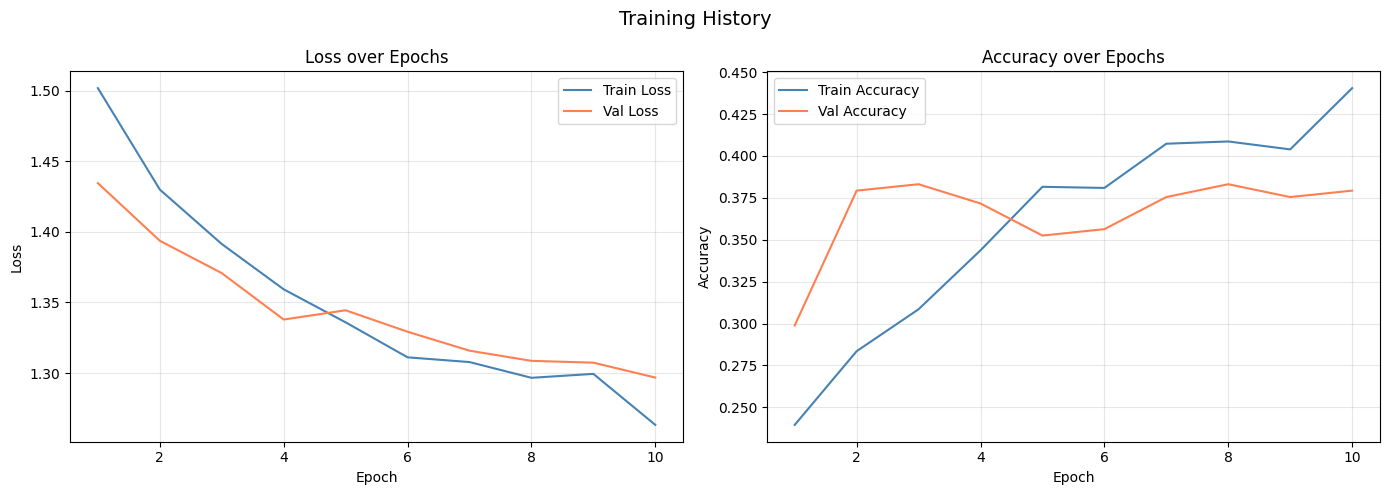

In [119]:
if not history['train_loss']:
    print('No fresh training history available. Using the loaded checkpoint, so skipping training plots.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=14)

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train Loss',  color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',    color='coral')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train Accuracy', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Val Accuracy',   color='coral')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Step 9 — Evaluation on the Test Set

This is the main section for understanding how well the model performs. We report:
- **Overall test accuracy**
- **Per-class precision, recall, and F1-score** (classification report)
- **Confusion matrix** — shows which classes are confused with each other

In [120]:
# Load the best checkpoint saved during training
if os.path.exists(BEST_MODEL_PATH):
    state_dict = torch.load(BEST_MODEL_PATH, map_location=CONFIG["device"])
    model.load_state_dict(state_dict)
    print(f"Best model weights loaded from {BEST_MODEL_PATH}.")
else:
    print(f"No saved checkpoint found at {BEST_MODEL_PATH}; using current model weights.")

model.eval()

# Build test DataLoader only if it does not already exist
if "test_loader" not in globals():
    test_loader = DataLoader(
        VideoDataset(test_df, is_train=False, split_name="test"),
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        collate_fn=crash_proof_collate,
        num_workers=NUM_WORKERS,
        pin_memory=(CONFIG["device"] == "cuda"),
    )

test_loss, test_acc, all_preds, all_labels = evaluate(
    model,
    test_loader,
    criterion,
    CONFIG["device"],
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc * 100:.1f}%)")


Best model weights loaded from c:\Users\arj20\action_recognition_project\data\best_model.pth.



Test Loss     : 1.3775
Test Accuracy : 0.3540 (35.4%)


In [121]:
if len(all_labels) == 0:
    raise ValueError("No valid test samples were evaluated. Check test_loader and dataset paths.")

# Only list class names that actually appear in the test set labels
present_labels = sorted(set(all_labels))
present_names = [CLASS_NAMES[label] for label in present_labels]

print("--- Classification Report ---")
print(
    classification_report(
        all_labels,
        all_preds,
        labels=present_labels,
        target_names=present_names,
        zero_division=0,
        digits=4,
    )
)



--- Classification Report ---
                 precision    recall  f1-score   support

normal_activity     0.2955    0.2167    0.2500       120
          fight     0.6031    0.4031    0.4832       196
           fall     0.2929    0.5190    0.3744        79
  running_panic     0.1053    0.2000    0.1379        40

       accuracy                         0.3540       435
      macro avg     0.3242    0.3347    0.3114       435
   weighted avg     0.4161    0.3540    0.3674       435



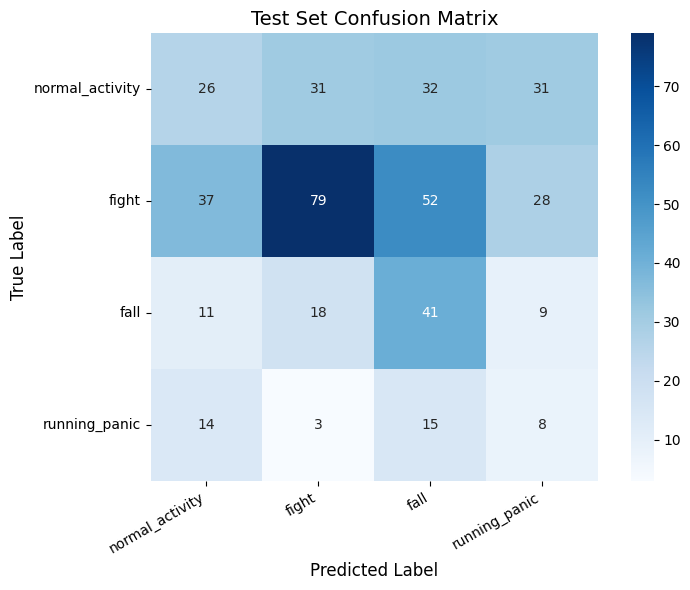


--- Per-Class Accuracy ---
normal_activity     : 0.2167 (26/120)
fight               : 0.4031 (79/196)
fall                : 0.5190 (41/79)
running_panic       : 0.2000 (8/40)


In [122]:
if len(all_labels) == 0:
    raise ValueError("No predictions available. Run the test evaluation cell first.")

# Rows = true class, columns = predicted class
cm = confusion_matrix(all_labels, all_preds, labels=present_labels)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=present_names,
    yticklabels=present_names,
    square=True,
    cbar=True,
)

plt.title("Test Set Confusion Matrix", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy = diagonal / row sum
print("\n--- Per-Class Accuracy ---")

for i, name in enumerate(present_names):
    row_sum = cm[i].sum()

    if row_sum > 0:
        per_class_acc = cm[i, i] / row_sum
        print(f"{name:<20}: {per_class_acc:.4f} ({cm[i, i]}/{row_sum})")
    else:
        print(f"{name:<20}: no test samples")


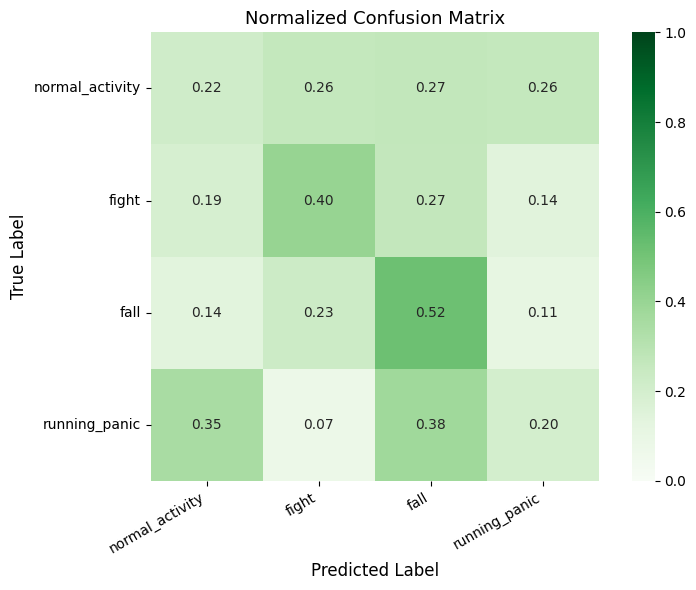

In [123]:
# Normalized confusion matrix
# Rows = true class, columns = predicted class
# Each row sums to 1.0 when that class has test samples.

with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    xticklabels=present_names,
    yticklabels=present_names,
    square=True,
    cbar=True,
)

plt.title("Normalized Confusion Matrix", fontsize=13)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 10 — GradCAM: What is the Model Looking At?

Generating GradCAM visualizations...


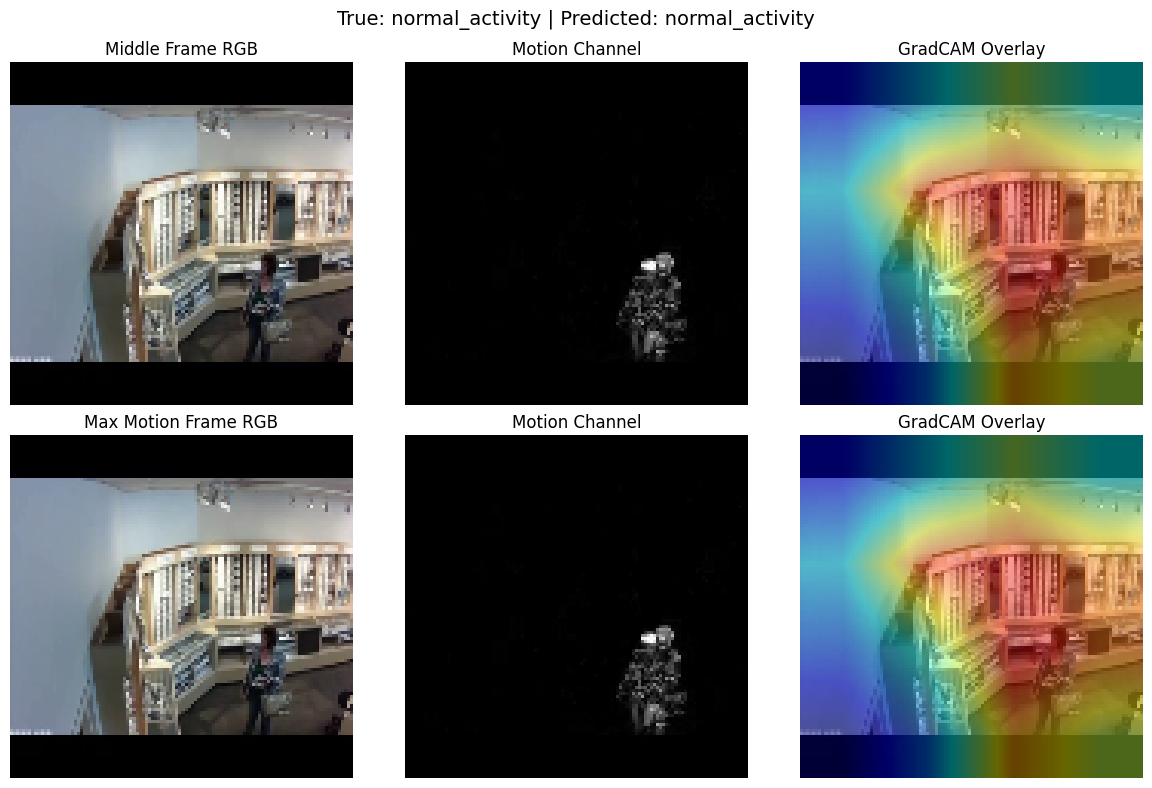

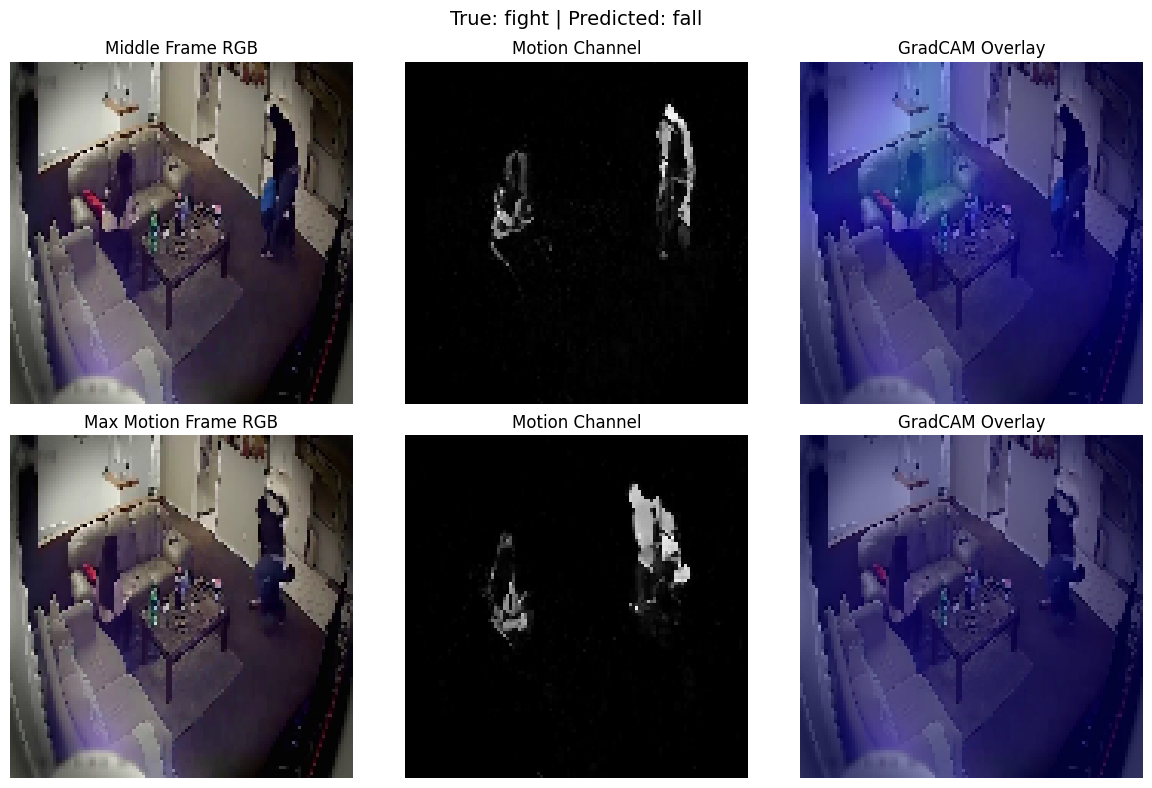

In [124]:
class GradCAM:
    """Generates a heatmap showing which spatial regions influenced the model decision."""

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def generate_cam(self, input_tensor, target_class=None):
        was_training = self.model.training

        # cuDNN LSTM backward requires train mode
        self.model.train()

        # Keep BatchNorm layers stable during GradCAM
        for module in self.model.backbone.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        self.model.zero_grad(set_to_none=True)

        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        logits = self.model(input_tensor)

        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        score = logits[0, target_class]
        score.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("GradCAM failed: gradients or activations were not captured.")

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam_min = cam.min()
        cam_max = cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        if not was_training:
            self.model.eval()

        return cam.detach().cpu().numpy(), target_class


def visualize_gradcam(model, video_path, true_label_name):
    size = CONFIG["image_size"]

    frames = extract_frames(
        video_path,
        num_frames=CONFIG["num_frames"],
        target_size=(size, size),
    )

    four_c = extract_motion_frames(frames)

    # Use the same validation transform used by the dataset
    tensor = apply_transforms(four_c, is_train=False)
    tensor = tensor.unsqueeze(0).to(CONFIG["device"])

    cam_extractor = GradCAM(model, model.backbone.layer4)

    try:
        cams, pred_idx = cam_extractor.generate_cam(tensor)
    finally:
        cam_extractor.remove_hooks()

    pred_name = CLASS_NAMES[pred_idx]

    mid_idx = CONFIG["num_frames"] // 2
    motion_scores = [np.mean(four_c[i, :, :, 3]) for i in range(CONFIG["num_frames"])]
    max_motion_idx = int(np.argmax(motion_scores))

    show_pairs = [
        (mid_idx, "Middle Frame"),
        (max_motion_idx, "Max Motion Frame"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f"True: {true_label_name} | Predicted: {pred_name}", fontsize=14)

    for row, (frame_idx, label) in enumerate(show_pairs):
        orig_img = frames[frame_idx]

        axes[row, 0].imshow(orig_img)
        axes[row, 0].set_title(f"{label} RGB")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(four_c[frame_idx, :, :, 3], cmap="gray")
        axes[row, 1].set_title("Motion Channel")
        axes[row, 1].axis("off")

        cam_up = cv2.resize(cams[frame_idx], (size, size))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        overlay = cv2.addWeighted(orig_img, 0.6, heatmap, 0.4, 0)

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("GradCAM Overlay")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


def get_class_video(dataframe, class_name):
    matches = dataframe[dataframe["class_name"] == class_name]

    if matches.empty:
        print(f"No validation video found for class: {class_name}")
        return None

    return matches.iloc[0]["video_path"]


print("Generating GradCAM visualizations...")

val_df = pd.read_csv(os.path.join(DATA_ROOT, "val.csv"))

normal_video = get_class_video(val_df, "normal_activity")
fight_video = get_class_video(val_df, "fight")

if normal_video is not None:
    visualize_gradcam(model, normal_video, "normal_activity")

if fight_video is not None:
    visualize_gradcam(model, fight_video, "fight")


## Step 11 — Motion Intensity Pre-Screening (Fast Filter)

Computing motion scores, up to 10 videos per class...


Motion scores: 100%|██████████| 40/40 [00:46<00:00,  1.15s/it]


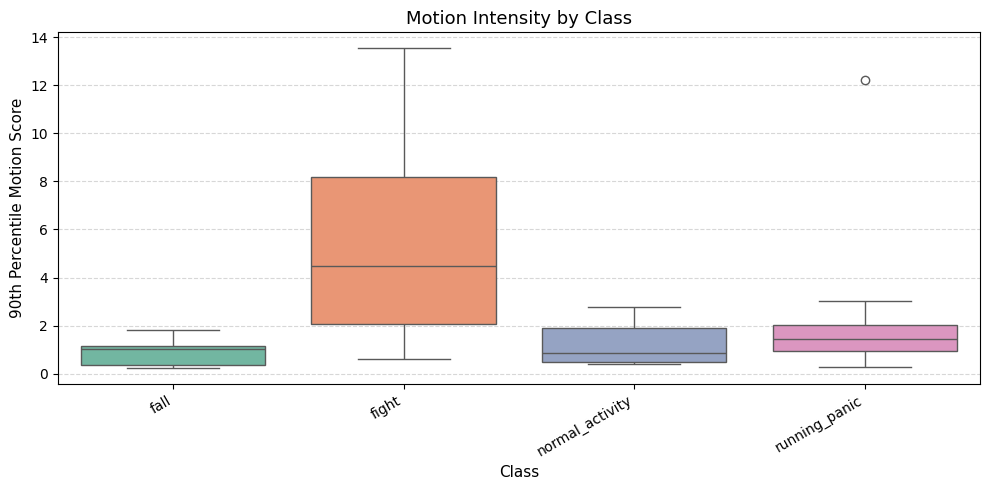


Average motion score per class:
class
fight              5.36
running_panic      2.50
normal_activity    1.25
fall               0.90


In [125]:
def compute_motion_score(video_path, max_frames=60):
    """
    Compute a 90th-percentile frame-difference score for a video.

    High score = lots of motion.
    Uses sampled frames for speed.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return 0.0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 1:
        cap.release()
        return 0.0

    frame_indices = np.linspace(0, total_frames - 1, min(max_frames, total_frames), dtype=int)

    prev_gray = None
    diffs = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ret, frame = cap.read()

        if not ret or frame is None:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is not None:
            diffs.append(np.mean(cv2.absdiff(gray, prev_gray)))

        prev_gray = gray

    cap.release()

    return float(np.percentile(diffs, 90)) if diffs else 0.0


# Sample up to 10 videos per class and compute motion scores
print("Computing motion scores, up to 10 videos per class...")

parts = []

for class_name in sorted(train_df["class_name"].unique()):
    subset = train_df[train_df["class_name"] == class_name]
    sample_size = min(10, len(subset))

    if sample_size > 0:
        parts.append(subset.sample(sample_size, random_state=42))

motion_sample = pd.concat(parts, ignore_index=True)

scores = []
labels = []

for _, row in tqdm(motion_sample.iterrows(), total=len(motion_sample), desc="Motion scores"):
    scores.append(compute_motion_score(row["video_path"]))
    labels.append(row["class_name"])

motion_df = pd.DataFrame({
    "class": labels,
    "score": scores,
})

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=motion_df,
    x="class",
    y="score",
    hue="class",
    palette="Set2",
    legend=False,
)

plt.title("Motion Intensity by Class", fontsize=13)
plt.xlabel("Class", fontsize=11)
plt.ylabel("90th Percentile Motion Score", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nAverage motion score per class:")
print(
    motion_df
    .groupby("class")["score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .to_string()
)


## Step 12 — Test-Time Augmentation (TTA)

In [126]:
def tta_predict(model, video_path, num_rounds=3):
    """
    Run the model multiple times on the same video using different frame-sampling
    strategies, then average probability scores.
    """
    model.eval()

    strategies = ["uniform", "random", "center_biased"]

    def get_frames(strategy):
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            return None

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            return None

        num_frames = CONFIG["num_frames"]
        image_size = CONFIG["image_size"]

        if strategy == "uniform":
            indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

        elif strategy == "random":
            replace = total_frames < num_frames
            indices = np.sort(
                np.random.choice(total_frames, num_frames, replace=replace)
            )

        else:
            start = int(total_frames * 0.2)
            end = int(total_frames * 0.8)

            if end <= start:
                start = 0
                end = total_frames

            indices = np.linspace(start, end - 1, num_frames, dtype=int)

        frames = []
        blank = np.zeros((image_size, image_size, 3), dtype=np.uint8)

        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
            ret, frame = cap.read()

            if ret and frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (image_size, image_size))
                frames.append(frame)
            else:
                frames.append(frames[-1].copy() if frames else blank.copy())

        cap.release()

        while len(frames) < num_frames:
            frames.append(frames[-1].copy() if frames else blank.copy())

        return np.array(frames, dtype=np.uint8)

    all_probs = []

    with torch.inference_mode():
        for round_idx in range(num_rounds):
            strategy = strategies[round_idx % len(strategies)]
            frames = get_frames(strategy)

            if frames is None:
                continue

            four_c = extract_motion_frames(frames)
            tensor = apply_transforms(four_c, is_train=False)
            tensor = tensor.unsqueeze(0).to(CONFIG["device"])

            logits = model(tensor)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            all_probs.append(probs)

    if not all_probs:
        return 0, np.zeros(CONFIG["num_classes"], dtype=np.float32)

    avg_probs = np.mean(all_probs, axis=0).astype(np.float32)
    pred_idx = int(np.argmax(avg_probs))

    return pred_idx, avg_probs


## Step 13 — Confidence Calibration

In [127]:
print("Computing per-class confidence thresholds on the validation set...")

val_probs = []
val_preds = []
val_true = []

model.eval()

with torch.inference_mode():
    for inputs, labels in val_loader:
        if inputs.numel() == 0:
            continue

        inputs = inputs.to(CONFIG["device"])
        labels = labels.to(CONFIG["device"])

        probs = F.softmax(model(inputs), dim=1)
        preds = probs.argmax(dim=1)

        val_probs.extend(probs.cpu().numpy())
        val_preds.extend(preds.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

val_probs = np.array(val_probs)
val_preds = np.array(val_preds)
val_true = np.array(val_true)

if len(val_true) == 0:
    raise ValueError("No validation samples were evaluated. Check val_loader.")

class_thresholds = {}

print("\n--- Calibration Results ---")

for class_idx in range(CONFIG["num_classes"]):
    class_name = CLASS_NAMES[class_idx]

    if class_idx not in set(val_true.tolist()):
        class_thresholds[class_idx] = 0.5
        print(f"{class_name:<20} no validation samples -> threshold: 0.50")
        continue

    predicted_as_class = val_preds == class_idx
    correct_as_class = (val_preds == class_idx) & (val_true == class_idx)
    incorrect_as_class = (val_preds == class_idx) & (val_true != class_idx)

    correct_conf = val_probs[correct_as_class, class_idx]
    incorrect_conf = val_probs[incorrect_as_class, class_idx]

    mean_correct = float(correct_conf.mean()) if len(correct_conf) > 0 else 0.5
    mean_incorrect = float(incorrect_conf.mean()) if len(incorrect_conf) > 0 else 0.0

    if len(incorrect_conf) > 0:
        threshold = float(np.percentile(incorrect_conf, 75))
    else:
        threshold = 0.4

    # Keep thresholds reasonable so calibration does not become too aggressive
    threshold = float(np.clip(threshold, 0.35, 0.85))
    class_thresholds[class_idx] = threshold

    print(
        f"{class_name:<20} "
        f"correct mean: {mean_correct:.2f} "
        f"incorrect mean: {mean_incorrect:.2f} "
        f"threshold: {threshold:.2f} "
        f"predicted samples: {int(predicted_as_class.sum())}"
    )


def calibrated_predict(probs, thresholds):
    """
    If the top prediction is below its class threshold,
    return the second-best class.
    """
    probs = np.asarray(probs)

    sorted_indices = np.argsort(probs)[::-1]
    top = int(sorted_indices[0])

    if probs[top] >= thresholds.get(top, 0.5):
        return top

    return int(sorted_indices[1])


Computing per-class confidence thresholds on the validation set...

--- Calibration Results ---
normal_activity      correct mean: 0.29 incorrect mean: 0.29 threshold: 0.35 predicted samples: 53
fight                correct mean: 0.30 incorrect mean: 0.29 threshold: 0.35 predicted samples: 72
fall                 correct mean: 0.30 incorrect mean: 0.30 threshold: 0.35 predicted samples: 89
crowd_anomaly        no validation samples -> threshold: 0.50
running_panic        correct mean: 0.29 incorrect mean: 0.29 threshold: 0.35 predicted samples: 47


## Step 14 — TTA + Calibration Evaluation on Test Set

Here we run the full production pipeline on the test set and compare it with the simple forward-pass result from Step 9.

In [128]:
print("Running TTA + calibration evaluation on the test set...")
print("This is slower because each non-normal-screened video is processed 3 times.\n")

NORMAL_CLASS_IDX = 0
MOTION_THRESHOLD = 2.0

tta_preds = []
tta_true = []
motion_screened = 0

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="TTA inference"):
    video_path = row["video_path"]
    true_label = int(row["label"])

    motion_score = compute_motion_score(video_path, max_frames=40)

    # Fast pre-screen: if there is barely any motion, predict normal
    if motion_score < MOTION_THRESHOLD:
        pred = NORMAL_CLASS_IDX
        motion_screened += 1
    else:
        _, probs = tta_predict(model, video_path, num_rounds=3)
        pred = calibrated_predict(probs, class_thresholds)

    tta_preds.append(int(pred))
    tta_true.append(true_label)

tta_acc = accuracy_score(tta_true, tta_preds)

print(f"\nTTA + calibration test accuracy : {tta_acc:.4f} ({tta_acc * 100:.1f}%)")
print(f"Simple forward-pass accuracy    : {test_acc:.4f} ({test_acc * 100:.1f}%)")
print(f"Accuracy difference             : {(tta_acc - test_acc) * 100:+.1f}%")
print(f"Motion-screened as normal       : {motion_screened}/{len(test_df)}")


Running TTA + calibration evaluation on the test set...
This is slower because each non-normal-screened video is processed 3 times.



TTA inference: 100%|██████████| 435/435 [09:03<00:00,  1.25s/it]


TTA + calibration test accuracy : 0.3540 (35.4%)
Simple forward-pass accuracy    : 0.3540 (35.4%)
Accuracy difference             : +0.0%
Motion-screened as normal       : 170/435


--- TTA + Calibration Classification Report ---
                 precision    recall  f1-score   support

normal_activity     0.3805    0.7167    0.4971       120
          fight     0.5618    0.2551    0.3509       196
           fall     0.0968    0.0759    0.0851        79
  running_panic     0.2069    0.3000    0.2449        40

       accuracy                         0.3540       435
      macro avg     0.3115    0.3369    0.2945       435
   weighted avg     0.3947    0.3540    0.3332       435



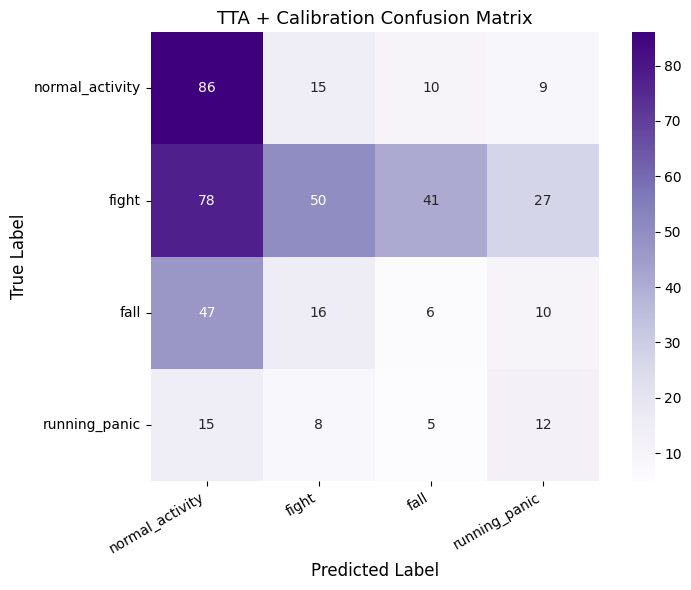

In [129]:
if len(tta_true) == 0:
    raise ValueError("No TTA predictions found. Run the TTA evaluation cell first.")

# TTA classification report
tta_present_labels = sorted(set(tta_true))
tta_present_names = [CLASS_NAMES[label] for label in tta_present_labels]

print("--- TTA + Calibration Classification Report ---")
print(
    classification_report(
        tta_true,
        tta_preds,
        labels=tta_present_labels,
        target_names=tta_present_names,
        zero_division=0,
        digits=4,
    )
)

# TTA confusion matrix
cm_tta = confusion_matrix(tta_true, tta_preds, labels=tta_present_labels)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tta,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=tta_present_names,
    yticklabels=tta_present_names,
    square=True,
    cbar=True,
)

plt.title("TTA + Calibration Confusion Matrix", fontsize=13)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 15 — Generate Submission CSV

In [130]:
print("Building submission.csv with the full inference pipeline...\n")

submission_rows = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Building submission"):
    video_path = row["video_path"]
    video_id = os.path.basename(video_path)

    motion_score = compute_motion_score(video_path, max_frames=40)

    if motion_score < MOTION_THRESHOLD:
        pred = NORMAL_CLASS_IDX
    else:
        _, probs = tta_predict(model, video_path, num_rounds=3)
        pred = calibrated_predict(probs, class_thresholds)

    submission_rows.append({
        "video_id": video_id,
        "predicted_label": int(pred),
        "predicted_class": CLASS_NAMES[int(pred)],
    })

submission_df = pd.DataFrame(submission_rows)

submission_csv = os.path.join(DATA_ROOT, "submission.csv")
submission_df.to_csv(submission_csv, index=False)

print(f"Submission saved to: {submission_csv}")

print("\n--- Predicted Class Distribution ---")
dist = submission_df["predicted_label"].value_counts().sort_index()

for label, count in dist.items():
    print(f"{CLASS_NAMES.get(label, label):<20} (label {label}): {count} videos")

submission_df.head()


Building submission.csv with the full inference pipeline...



Building submission: 100%|██████████| 435/435 [09:03<00:00,  1.25s/it]

Submission saved to: c:\Users\arj20\action_recognition_project\data\submission.csv

--- Predicted Class Distribution ---
normal_activity      (label 0): 226 videos
fight                (label 1): 85 videos
fall                 (label 2): 60 videos
running_panic        (label 4): 64 videos


,video_id,predicted_label,predicted_class
0,YOUTUBE_YouTubeCCTV020_sit_1.mp4,0,normal_activity
1,YOUTUBE_YouTubeCCTV079_struggle_3.mp4,1,fight
2,YOUTUBE_YouTubeCCTV222_kick_1.mp4,0,normal_activity
3,NTU_fight0031_throw_1.mp4,1,fight
4,YOUTUBE_YouTubeCCTV049_lying_down_1.mp4,2,fall


Loaded model from: c:\Users\arj20\action_recognition_project\data\best_model.pth
Running inference on 5 random test videos...

Sample 1
Video           : UCFCRIME_Robbery004_stand_1.mp4
True label      : 0
True class      : normal_activity
Predicted label : 4
Predicted class : running_panic
Confidence      : 0.2941
Correct         : False

Class probabilities:
0 - normal_activity     : 0.2930
1 - fight               : 0.2120
2 - fall                : 0.1674
3 - crowd_anomaly       : 0.0334
4 - running_panic       : 0.2941


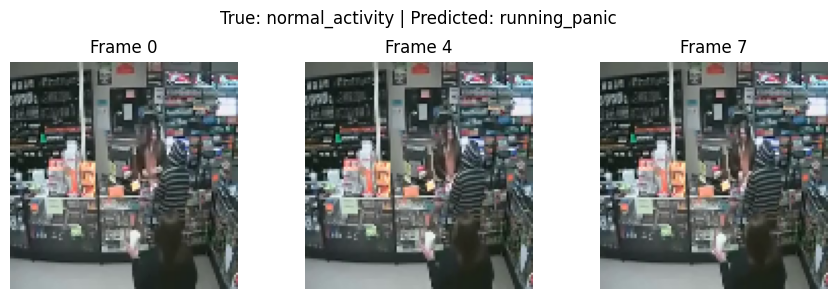

Sample 2
Video           : YOUTUBE_YouTubeCCTV005_fall_6.mp4
True label      : 2
True class      : fall
Predicted label : 2
Predicted class : fall
Confidence      : 0.3077
Correct         : True

Class probabilities:
0 - normal_activity     : 0.2258
1 - fight               : 0.1994
2 - fall                : 0.3077
3 - crowd_anomaly       : 0.0207
4 - running_panic       : 0.2464


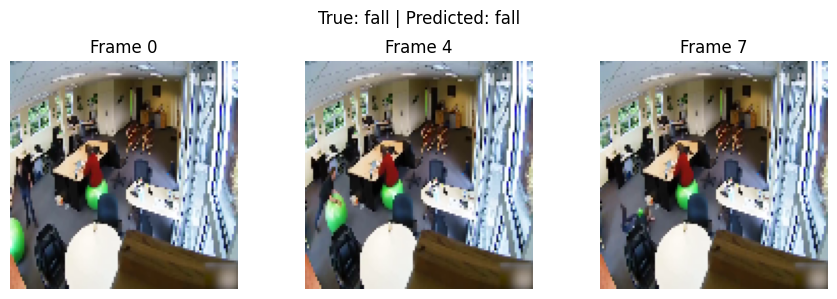

Sample 3
Video           : YOUTUBE_YouTubeCCTV117_gun_1.mp4
True label      : 1
True class      : fight
Predicted label : 1
Predicted class : fight
Confidence      : 0.2827
Correct         : True

Class probabilities:
0 - normal_activity     : 0.2616
1 - fight               : 0.2827
2 - fall                : 0.2315
3 - crowd_anomaly       : 0.0231
4 - running_panic       : 0.2011


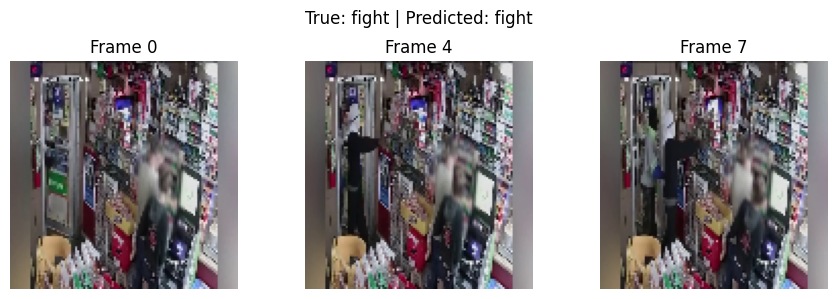

Sample 4
Video           : YOUTUBE_YouTubeCCTV001_fall_44.mp4
True label      : 2
True class      : fall
Predicted label : 2
Predicted class : fall
Confidence      : 0.3703
Correct         : True

Class probabilities:
0 - normal_activity     : 0.1448
1 - fight               : 0.2035
2 - fall                : 0.3703
3 - crowd_anomaly       : 0.0372
4 - running_panic       : 0.2443


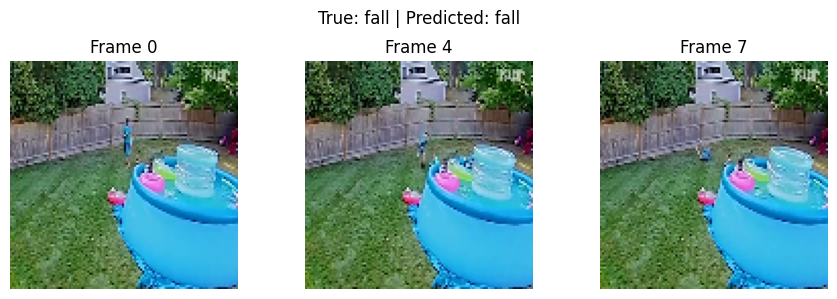

Sample 5
Video           : YOUTUBE_YouTubeCCTV002_sit_3.mp4
True label      : 0
True class      : normal_activity
Predicted label : 1
Predicted class : fight
Confidence      : 0.3158
Correct         : False

Class probabilities:
0 - normal_activity     : 0.2463
1 - fight               : 0.3158
2 - fall                : 0.1908
3 - crowd_anomaly       : 0.0234
4 - running_panic       : 0.2237


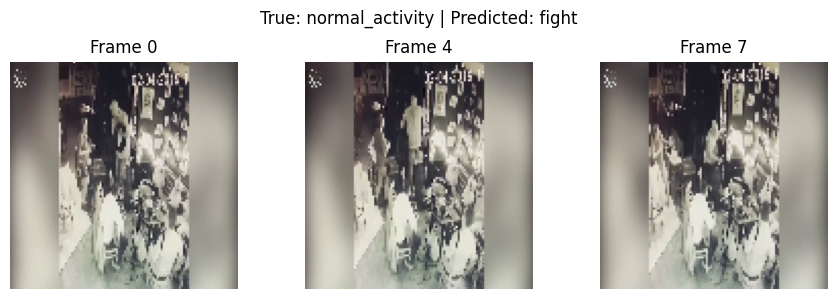

In [131]:
def classify_single_video(video_path):
    if not video_path or not os.path.exists(video_path):
        raise FileNotFoundError(f"No valid video found: {video_path}")

    model.eval()

    size = CONFIG["image_size"]

    frames = extract_frames(
        video_path,
        num_frames=CONFIG["num_frames"],
        target_size=(size, size),
    )

    four_c = extract_motion_frames(frames)
    tensor = apply_transforms(four_c, is_train=False)
    tensor = tensor.unsqueeze(0).to(CONFIG["device"])

    with torch.inference_mode():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_label = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_label]
    confidence = float(probs[pred_label])

    return pred_label, pred_class, confidence, probs, frames


# Load best saved model if available
if "BEST_MODEL_PATH" in globals() and os.path.exists(BEST_MODEL_PATH):
    state_dict = torch.load(BEST_MODEL_PATH, map_location=CONFIG["device"])
    model.load_state_dict(state_dict)
    print(f"Loaded model from: {BEST_MODEL_PATH}")

# Pick random videos from test set
NUM_RANDOM_VIDEOS = 5

sample_df = test_df.sample(
    min(NUM_RANDOM_VIDEOS, len(test_df)),
    random_state=None,
).reset_index(drop=True)

print(f"Running inference on {len(sample_df)} random test videos...\n")

for i, row in sample_df.iterrows():
    video_path = row["video_path"]
    true_label = int(row["label"])
    true_class = row["class_name"]

    pred_label, pred_class, confidence, probs, frames = classify_single_video(video_path)

    print("=" * 70)
    print(f"Sample {i + 1}")
    print(f"Video           : {os.path.basename(video_path)}")
    print(f"True label      : {true_label}")
    print(f"True class      : {true_class}")
    print(f"Predicted label : {pred_label}")
    print(f"Predicted class : {pred_class}")
    print(f"Confidence      : {confidence:.4f}")
    print(f"Correct         : {pred_label == true_label}")

    print("\nClass probabilities:")
    for label_idx, prob in enumerate(probs):
        print(f"{label_idx} - {CLASS_NAMES[label_idx]:<20}: {prob:.4f}")

    # Show a few sampled frames
    show_indices = [0, CONFIG["num_frames"] // 2, CONFIG["num_frames"] - 1]

    plt.figure(figsize=(9, 3))
    for j, frame_idx in enumerate(show_indices):
        plt.subplot(1, 3, j + 1)
        plt.imshow(frames[frame_idx])
        plt.title(f"Frame {frame_idx}")
        plt.axis("off")

    plt.suptitle(f"True: {true_class} | Predicted: {pred_class}")
    plt.tight_layout()
    plt.show()


In [136]:
import os
import tkinter as tk
from tkinter import filedialog

def choose_video_file():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)

    video_path = filedialog.askopenfilename(
        title="Select a video file",
        filetypes=[
            ("Video files", "*.mp4 *.avi *.mov *.mkv"),
            ("All files", "*.*"),
        ],
    )

    root.destroy()
    return video_path


def classify_single_video(video_path):
    if not video_path or not os.path.exists(video_path):
        raise FileNotFoundError("No valid video selected.")

    model.eval()

    size = CONFIG["image_size"]

    frames = extract_frames(
        video_path,
        num_frames=CONFIG["num_frames"],
        target_size=(size, size),
    )

    four_c = extract_motion_frames(frames)
    tensor = apply_transforms(four_c, is_train=False)
    tensor = tensor.unsqueeze(0).to(CONFIG["device"])

    with torch.inference_mode():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_label = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_label]
    confidence = float(probs[pred_label])

    return pred_label, pred_class, confidence, probs


# Optional: load best saved model if available
if "BEST_MODEL_PATH" in globals() and os.path.exists(BEST_MODEL_PATH):
    state_dict = torch.load(BEST_MODEL_PATH, map_location=CONFIG["device"])
    model.load_state_dict(state_dict)
    print(f"Loaded model from: {BEST_MODEL_PATH}")

video_path = choose_video_file()

if video_path:
    pred_label, pred_class, confidence, probs = classify_single_video(video_path)

    print("Prediction Result")
    print("-" * 50)
    print(f"Video           : {video_path}")
    print(f"Predicted label : {pred_label}")
    print(f"Predicted class : {pred_class}")
    print(f"Confidence      : {confidence:.4f}")

    print("\nClass probabilities:")
    for label_idx, prob in enumerate(probs):
        print(f"{label_idx} - {CLASS_NAMES[label_idx]:<20}: {prob:.4f}")
else:
    print("No video selected.")


Loaded model from: c:\Users\arj20\action_recognition_project\data\best_model.pth
Prediction Result
--------------------------------------------------
Video           : C:/Users/arj20/Videos/Screen Recordings/Screen Recording 2026-04-29 201833.mp4
Predicted label : 1
Predicted class : fight
Confidence      : 0.3270

Class probabilities:
0 - normal_activity     : 0.1990
1 - fight               : 0.3270
2 - fall                : 0.2394
3 - crowd_anomaly       : 0.0161
4 - running_panic       : 0.2185
